In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/titanic_1M.csv')

print("--- First 5 Rows ---")
print(df.head())
print("\n--- Data Info ---")
df.info()
print("\n--- Statistical Summary ---")
print(df.describe())

--- First 5 Rows ---
   PassengerId  Survived  Pclass                         Name     Sex   Age  \
0         1310         1       1  Name1310, Miss. Surname1310  female   NaN   
1         1311         0       3   Name1311, Col. Surname1311    male  29.0   
2         1312         0       3    Name1312, Mr. Surname1312    male  20.0   
3         1313         0       3    Name1313, Mr. Surname1313    male  27.0   
4         1314         0       3    Name1314, Mr. Surname1314    male  32.0   

   SibSp  Parch            Ticket       Fare Cabin Embarked  
0      0      0  SOTON/O2 3101272  76.760165   NaN        C  
1      0      0            223596  10.193097   NaN        S  
2      0      0             54636  12.029416   C83        C  
3      0      0          PC 17760  13.429448   NaN        S  
4      0      0            364512   4.840769   E33        C  

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column 

In [4]:
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

df.drop_duplicates(inplace=True)

print("Data successfully cleaned. Remaining null values:")
print(df.isnull().sum())

Data successfully cleaned. Remaining null values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


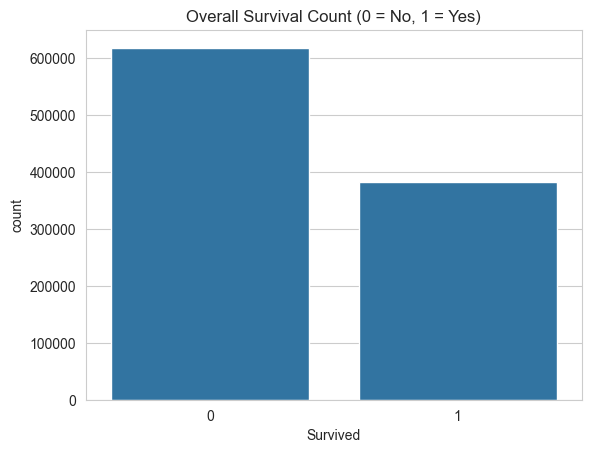

In [5]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=df)
plt.title('Overall Survival Count (0 = No, 1 = Yes)');

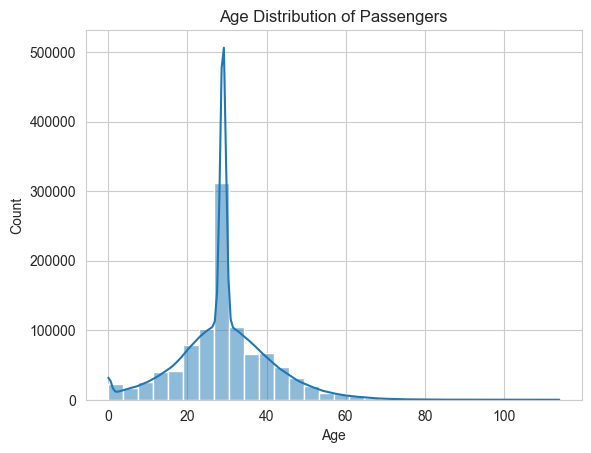

In [6]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age');

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df_model = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
target = 'Survived'

X = df_model[[col for col in features if col in df_model.columns]]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 80.23%
